This ipynb:
- Resize to 128×128
- Normalize to [0,1]
- Create Raw images
- Apply Global Histogram Equalization
- Apply CLAHE
- Show Raw vs GHE vs CLAHE
- Plot intensity histograms
- Split data into train/validation/test

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
PROJECT_DIR = Path.cwd().parent

DATASET_PATH = PROJECT_DIR / "data" / "brain_tumor_dataset"

OUTPUT_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR = OUTPUT_DIR / "processed"
FIGURES_DIR = OUTPUT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATASET_PATH)
print("Processed output directory:", PROCESSED_DIR)
print("Dataset exists:", DATASET_PATH.exists())

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Dataset path: C:\Users\elifn\DSAI 583\PROJECT\data\brain_tumor_dataset
Processed output directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed
Dataset exists: True


In [4]:
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

yes_paths = [
    path for path in (DATASET_PATH / "yes").iterdir()
    if path.suffix.lower() in valid_extensions
]

no_paths = [
    path for path in (DATASET_PATH / "no").iterdir()
    if path.suffix.lower() in valid_extensions
]

data = []

for path in yes_paths:
    data.append({
        "path": path,
        "label": 1,
        "class_name": "tumor"
    })

for path in no_paths:
    data.append({
        "path": path,
        "label": 0,
        "class_name": "no_tumor"
    })

df = pd.DataFrame(data)

print("Total images:", len(df))
print(df["class_name"].value_counts())

Total images: 253
class_name
tumor       155
no_tumor     98
Name: count, dtype: int64


### Train / Validation / Test Split

I divide this dataset into 70% training, 15% validation, and 15% testing.  
Chose stratified splitting so that tumor and non-tumor images represented proportionally in each split.

In [5]:
RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 177
Validation images: 38
Testing images: 38


In [6]:
# class distributions
print("Train distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train distribution:
class_name
tumor       108
no_tumor     69
Name: count, dtype: int64

Validation distribution:
class_name
tumor       24
no_tumor    14
Name: count, dtype: int64

Test distribution:
class_name
tumor       23
no_tumor    15
Name: count, dtype: int64


### Preprocessing methods
- Raw: resized image without contrast enhancement
- GHE: global histogram equalization
- CLAHE: local adaptive histogram equalization with contrast limiting

Histogram equalization comes before normalization because OpenCV equalization functions expect 8bit grayscale images.

In [8]:
IMAGE_SIZE = (128, 128)


def read_and_resize_image(image_path):
    """
    Reads an image in grayscale and resizes it to 128x128.
    """
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    image = cv2.resize(image, IMAGE_SIZE)
    
    return image


def apply_ghe(image):
    """
    Applies Global Histogram Equalization.
    """
    return cv2.equalizeHist(image)


def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applies Contrast Limited Adaptive Histogram Equalization.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    
    return clahe.apply(image)


def normalize_image(image):
    """
    Converts pixel values from [0,255] to [0,1].
    """
    return image.astype("float32") / 255.0


def preprocess_image(image_path, method):
    """
    Reads, resizes, enhances if needed, and normalizes one image.
    
    method can be:
    - raw
    - ghe
    - clahe
    """
    image = read_and_resize_image(image_path)
    
    if method == "raw":
        processed = image
    elif method == "ghe":
        processed = apply_ghe(image)
    elif method == "clahe":
        processed = apply_clahe(image)
    else:
        raise ValueError("method must be 'raw', 'ghe', or 'clahe'")
    processed = normalize_image(processed)
    
    return processed

### Visual Comparison
1 sample image => processed using three methods 

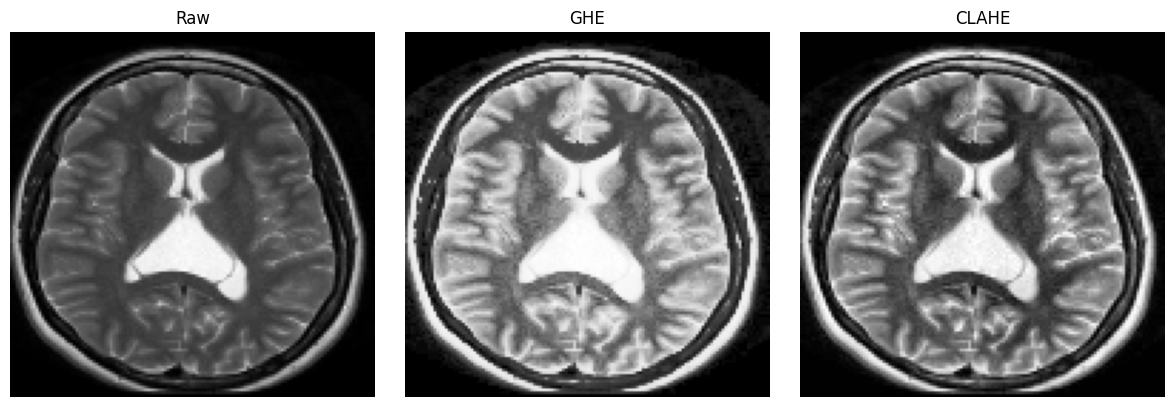

In [9]:
sample_path = train_df[train_df["class_name"] == "tumor"].iloc[0]["path"]

raw_uint8 = read_and_resize_image(sample_path)
ghe_uint8 = apply_ghe(raw_uint8)
clahe_uint8 = apply_clahe(raw_uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(raw_uint8, cmap="gray")
plt.title("Raw")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ghe_uint8, cmap="gray")
plt.title("GHE")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clahe_uint8, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

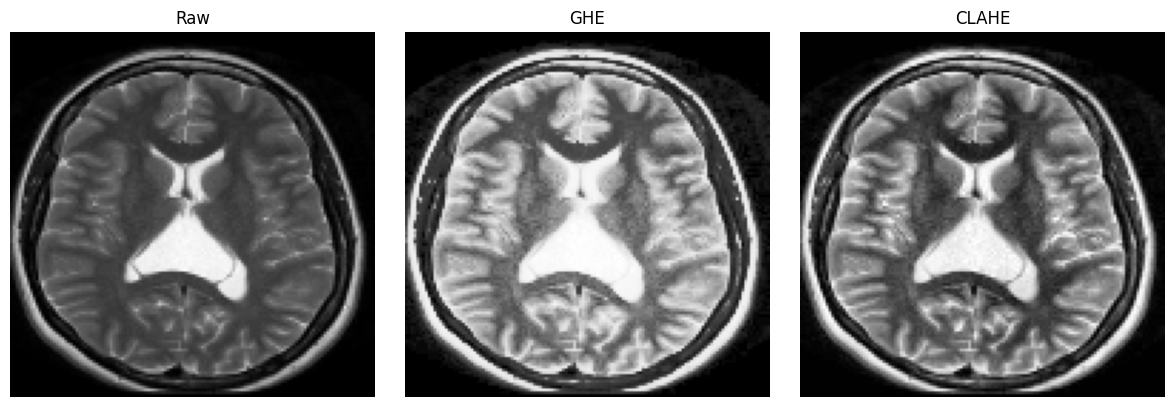

In [10]:
plt.figure(figsize=(12, 4))

for i, (image, title) in enumerate([
    (raw_uint8, "Raw"),
    (ghe_uint8, "GHE"),
    (clahe_uint8, "CLAHE")
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "raw_ghe_clahe_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

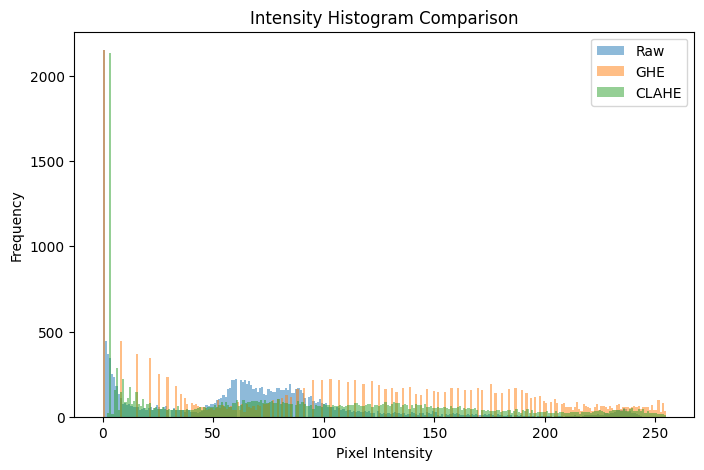

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(raw_uint8.ravel(), bins=256, alpha=0.5, label="Raw")
plt.hist(ghe_uint8.ravel(), bins=256, alpha=0.5, label="GHE")
plt.hist(clahe_uint8.ravel(), bins=256, alpha=0.5, label="CLAHE")

plt.title("Intensity Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

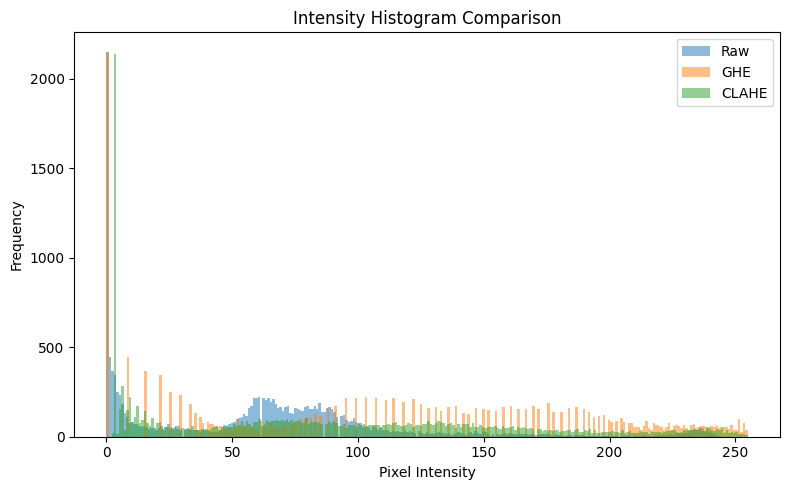

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(raw_uint8.ravel(), bins=256, alpha=0.5, label="Raw")
plt.hist(ghe_uint8.ravel(), bins=256, alpha=0.5, label="GHE")
plt.hist(clahe_uint8.ravel(), bins=256, alpha=0.5, label="CLAHE")

plt.title("Intensity Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "intensity_histogram_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Creating Processed Datasets

Each image is processed into => Raw, GHE, and CLAHE
The labels and the train/validation/test split remain same for all methods

In [13]:
def process_dataframe(dataframe, method):
    """
    Processes all images in a dataframe using the selected preprocessing method.
    Returns X and y arrays.
    """
    images = []
    labels = []
    
    for _, row in dataframe.iterrows():
        image = preprocess_image(row["path"], method)
        label = row["label"]
        
        images.append(image)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    # Add channel dimension: (samples, height, width, channels)
    X = np.expand_dims(X, axis=-1)
    
    return X, y

In [14]:
methods = ["raw", "ghe", "clahe"]

datasets = {}

for method in methods:
    print(f"Processing method: {method}")
    
    X_train, y_train = process_dataframe(train_df, method)
    X_val, y_val = process_dataframe(val_df, method)
    X_test, y_test = process_dataframe(test_df, method)
    
    datasets[method] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }
    
    print("X_train:", X_train.shape)
    print("X_val:", X_val.shape)
    print("X_test:", X_test.shape)
    print()

Processing method: raw
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

Processing method: ghe
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

Processing method: clahe
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)



In [15]:
for method in methods:
    X_train = datasets[method]["X_train"]
    
    print(method)
    print("Minimum pixel value:", X_train.min())
    print("Maximum pixel value:", X_train.max())
    print("Shape:", X_train.shape)
    print()

#checking normalization

raw
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape: (177, 128, 128, 1)

ghe
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape: (177, 128, 128, 1)

clahe
Minimum pixel value: 0.003921569
Maximum pixel value: 1.0
Shape: (177, 128, 128, 1)



In [16]:
for method in methods:
    np.savez_compressed(
        PROCESSED_DIR / f"{method}_data.npz",
        X_train=datasets[method]["X_train"],
        y_train=datasets[method]["y_train"],
        X_val=datasets[method]["X_val"],
        y_val=datasets[method]["y_val"],
        X_test=datasets[method]["X_test"],
        y_test=datasets[method]["y_test"]
    )
    
    print(f"Saved: {PROCESSED_DIR / f'{method}_data.npz'}")

Saved: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed\raw_data.npz
Saved: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed\ghe_data.npz
Saved: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed\clahe_data.npz


In [18]:
summary = []

for method in methods:
    summary.append({
        "method": method,
        "train_samples": datasets[method]["X_train"].shape[0],
        "val_samples": datasets[method]["X_val"].shape[0],
        "test_samples": datasets[method]["X_test"].shape[0],
        "image_shape": datasets[method]["X_train"].shape[1:]
    })

summary_df = pd.DataFrame(summary)
summary_df

,method,train_samples,val_samples,test_samples,image_shape
0,raw,177,38,38,"(128, 128, 1)"
1,ghe,177,38,38,"(128, 128, 1)"
2,clahe,177,38,38,"(128, 128, 1)"


1. Raw MRI images
2. GHE-enhanced MRI images
3. CLAHE-enhanced MRI images
are created.

All images were resized to 128×128 and normalized to [0,1].  
The same 70/15/15 train-validation-test split was used for all preprocessing methods.